In [1]:
# Sample Data

import pandas as pd
import Log_metrics_extract as lm
import os

# Create a dummy dataframe structure to simulate the actual CSV
columns = [
    "iteration",
    "layer_1_channels", "layer_1_filter", "layer_1_padding", "layer_1_param_count",
    "layer_2_channels", "layer_2_filter", "layer_2_padding", "layer_2_param_count",
    "layer_3_channel", "layer_3_filter", "layer_3_padding", "layer_3_param_count",
    "total_param_count"
]

# Generate a small sample to test the plotting functions
df = pd.DataFrame({
    "iteration": range(10),
    "layer_1_channels": [16, 32, 16, 16, 64, 64, 32, 64, 16, 16],
    "layer_1_filter": [3, 5, 3, 3, 5, 5, 7, 3, 3, 7],
    "layer_1_padding": [1, 2, 1, 1, 2, 0, 0, 1, 2, 1],
    "layer_1_param_count": [100]*10,
    "layer_2_channels": [64, 64, 64, 32, 64, 32, 64, 32, 64, 32],
    "layer_2_filter": [3, 3, 5, 3, 5, 5, 7, 3, 3, 7],
    "layer_2_padding": [1, 1, 2, 1, 2, 0, 0, 1, 2, 1],
    "layer_2_param_count": [200]*10,
    "layer_3_channels": [128, 64, 64, 128, 64, 128, 64, 128, 64, 128],
    "layer_3_filter": [3, 3, 5, 3, 5, 5, 7, 3, 3, 7],
    "layer_3_padding": [1, 1, 2, 1, 2, 0, 0, 1, 2, 1],
    "layer_3_param_count": [300]*10,
    "total_param_count": [600]*10
})

df.head()


,iteration,layer_1_channels,layer_1_filter,layer_1_padding,layer_1_param_count,layer_2_channels,layer_2_filter,layer_2_padding,layer_2_param_count,layer_3_channels,layer_3_filter,layer_3_padding,layer_3_param_count,total_param_count
0,0,16,3,1,100,64,3,1,200,128,3,1,300,600
1,1,32,5,2,100,64,3,1,200,64,3,1,300,600
2,2,16,3,1,100,64,5,2,200,64,5,2,300,600
3,3,16,3,1,100,32,3,1,200,128,3,1,300,600
4,4,64,5,2,100,64,5,2,200,64,5,2,300,600


In [2]:
import matplotlib.pyplot as plt

def plot_token_distribution(df, include_layer1=True, use_sns=False, sns_palette="tab20c"):
    """
    Plot token distributions (channels, filter, padding) in a 1x3 subplot layout.

    Args:
        df (pd.DataFrame): DataFrame containing architecture logs.
        include_layer1 (bool): Whether to include layer 1 in the plots.
        use_sns (bool): Whether to use seaborn or matplotlib styles.
    """
    token_map = {
        "channels": ["layer_1_channels", "layer_2_channels", "layer_3_channels"],
        "filter": ["layer_1_filter", "layer_2_filter", "layer_3_filter"],
        "padding": ["layer_1_padding", "layer_2_padding", "layer_3_padding"]
    }

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    fig.suptitle("Experiment Token Distribution", fontsize=16)

    for i, token_type in enumerate(["channels", "filter", "padding"]):
        layers = token_map[token_type]
        if not include_layer1:
            layers = layers[1:]

        df_tokens = df[layers].copy()
        df_tokens.columns = [f"Layer {j+1 if include_layer1 else j+2}" for j in range(len(layers))]
        df_melted = df_tokens.melt(var_name="Layer", value_name="Token")

        token_counts = df_melted.groupby(["Layer", "Token"]).size().reset_index(name="Count")
        pivot = token_counts.pivot(index="Layer", columns="Token", values="Count").fillna(0)

        ax = axs[i]
        pivot.plot(kind="bar", stacked=True, ax=ax, colormap=sns_palette if use_sns else None)
        ax.set_title(f"{token_type.capitalize()} Token Distribution")
        ax.set_ylabel("Count")
        ax.set_xlabel("Layer")
        ax.set_xticklabels(pivot.index, rotation=0)
        ax.legend(title=token_type.capitalize(), bbox_to_anchor=(1.05, 1), loc="upper left")
        ax.grid(axis='y')

    plt.tight_layout()
    plt.show()


In [3]:
def generate_token_distribution_csv(experiment_name):
    log_file_dir = os.path.join("LogFiles", "TrainingLogs")
    log_output_dir = os.path.join("LogFiles", "Output")
    os.makedirs(log_file_dir, exist_ok=True)
    os.makedirs(log_output_dir, exist_ok=True)

    log_file_path = os.path.join(log_file_dir, f"{experiment_name}.log")
    log_output_path = os.path.join(log_output_dir, f"{experiment_name}_log.csv")

    if not os.path.exists(log_file_path):
        raise FileNotFoundError(f"Log file does not exist at : {log_file_path}")


    lm.parse_training_log(log_file_path, log_output_path)

In [4]:
experiment_name = "EXP4_CIFAR_100_Pre_Trained"

generate_token_distribution_csv(experiment_name)

✅ Fixed padding captured and exported 300 models to LogFiles\Output\EXP4_CIFAR_100_Pre_Trained_log.csv


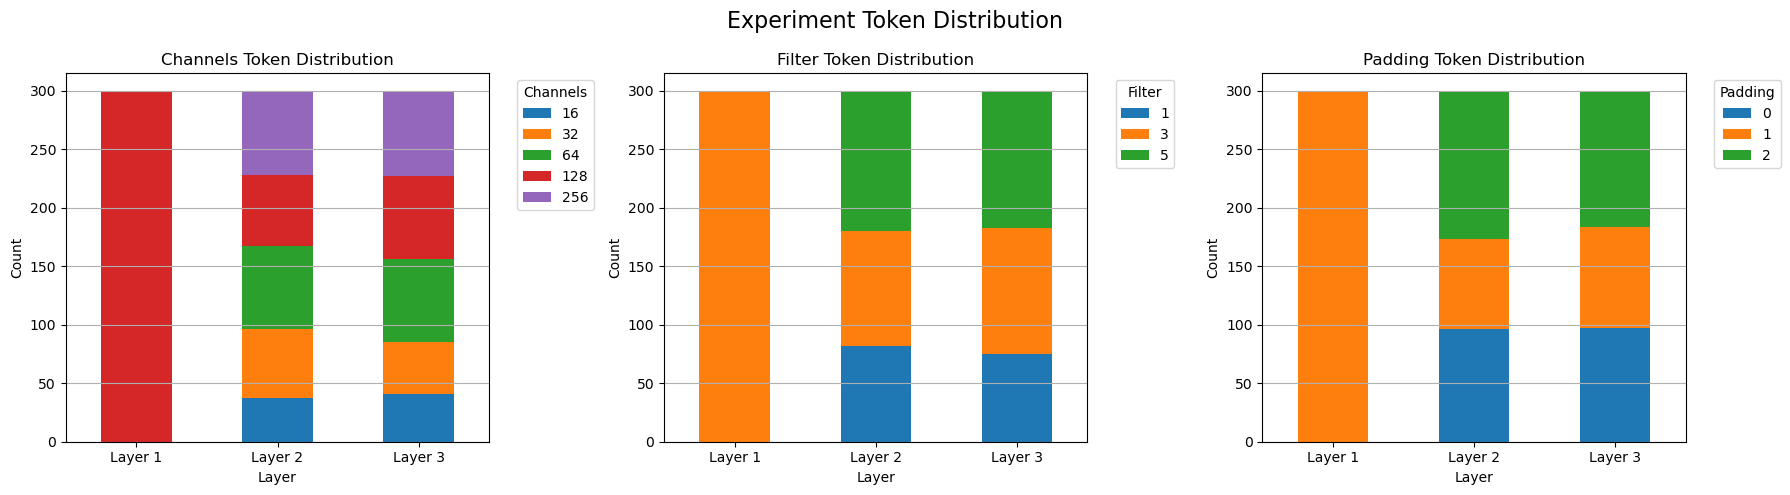

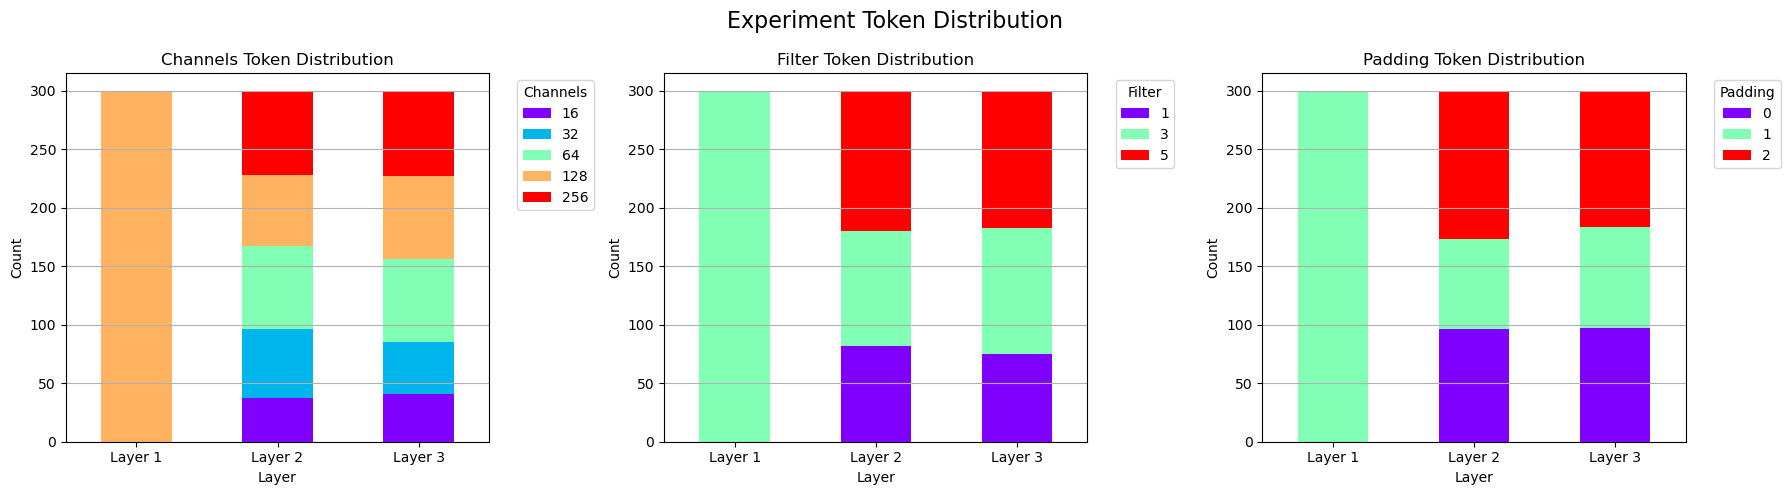

In [7]:
# Matplotlib version
path = os.path.join("LogFiles", "Output", f"{experiment_name}_log.csv")
df = pd.read_csv(path)


plot_token_distribution(df, include_layer1=True, use_sns=False)

# Seaborn version
plot_token_distribution(df, include_layer1=True, use_sns=True, sns_palette="rainbow")


In [8]:
experiment_name = "EXP_6_CIFAR10"
df = pd.read_csv(os.path.join("Results", "Controller", "CNN", f"{experiment_name}.csv"))
print(df.head())

df.describe()

   train_loss  val_loss  test_acc  train_time  policy_gradient  max_accuracy  \
0    0.642527  0.677846    0.7658   94.129953         0.081712        0.7658   
1    0.625208  0.640382    0.7826   64.795565         0.769014        0.7826   
2    0.810081  0.773788    0.7307   66.230641         0.631927        0.7826   
3    0.831395  0.779634    0.7293   63.859987         0.237514        0.7826   
4    0.700526  0.697938    0.7581   63.820858         0.563878        0.7826   

   baseline  
0  0.001219  
1  0.010584  
2  0.018929  
3  0.021818  
4  0.029931  


,train_loss,val_loss,test_acc,train_time,policy_gradient,max_accuracy,baseline
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.704474,0.677215,0.765384,61.850851,0.004803,0.811828,0.097031
std,0.083589,0.066696,0.024998,3.020462,0.153478,0.005265,0.015972
min,0.518543,0.553475,0.629100,58.534355,-0.648091,0.765800,0.001219
25%,0.646092,0.630811,0.751050,60.241490,-0.050738,0.811600,0.091286
50%,0.691313,0.664099,0.770500,60.830967,0.019744,0.815100,0.101679
75%,0.756210,0.717110,0.782600,62.406214,0.072308,0.815100,0.107042
max,1.097841,1.035432,0.815100,94.129953,0.769014,0.815100,0.117871


In [9]:
def compute_grouped_stats(df, step=50, metrics=None, stats=None):
    if metrics is None:
        metrics = df.columns.tolist()
    if stats is None:
        stats = ['mean', 'std', 'min', '25%', '50%', '75%', 'max']

    df = df.copy()
    df["row_index"] = df.index
    df["range_label"] = df["row_index"].apply(lambda x: f"{(x // step) * step}-{(x // step + 1) * step - 1}")

    grouped = df.groupby("range_label", sort=False)[metrics].describe()

    if isinstance(grouped.columns, pd.MultiIndex):
        grouped = grouped.loc[:, grouped.columns.get_level_values(1).isin(stats)]

    return grouped


# Example usage
grouped_result = compute_grouped_stats(df, step=50, metrics=["test_acc", "train_time"], stats=["mean", "std"])
grouped_result

test_acc           train_time          
                 mean       std       mean       std
range_label                                         
0-49         0.754944  0.033403  65.211339  5.999812
50-99        0.765864  0.029342  63.512239  3.864713
100-149      0.766268  0.026724  61.771484  2.096923
150-199      0.759716  0.025922  61.544825  1.877898
200-249      0.758964  0.026249  61.136107  1.742308
250-299      0.768060  0.023425  61.354258  1.791589
300-349      0.764010  0.021012  61.120550  1.602077
350-399      0.769524  0.022026  60.971053  1.529296
400-449      0.770244  0.016837  60.887601  1.058149
450-499      0.776248  0.013962  60.999057  1.882489

In [29]:
def get_combined_df(experiment_name):
    df_train_log = pd.read_csv(os.path.join("Results", "Controller", "CNN", f"{experiment_name}.csv"))
    df_stats = pd.read_csv(os.path.join("LogFiles", "Output", f"{experiment_name}_log.csv"))

    return  pd.concat((df_train_log, df_stats), axis=1)

def find_best_row_in_first_300(df,limit=300):
    df = df.head(limit)
    return combined_df.loc[df['max_accuracy'].idxmax()]

combined_df = get_combined_df(experiment_name)
find_best_row_in_first_300(combined_df)

# combined_df.columns

# compute_grouped_stats(get_combined_df(experiment_name), step=50, metrics=["test_acc", "train_time", "total_param_count"], stats=["mean", "std"])

train_loss                  0.528154
val_loss                    0.557713
test_acc                    0.815100
train_time                 61.721988
policy_gradient            -0.334864
max_accuracy                0.815100
baseline                    0.100247
iteration                 231.000000
layer_1_channels          128.000000
layer_1_filter              3.000000
layer_1_padding             1.000000
layer_1_param_count      3584.000000
layer_2_channels           64.000000
layer_2_filter              3.000000
layer_2_padding             1.000000
layer_2_param_count     73792.000000
layer_3_channels          256.000000
layer_3_filter              3.000000
layer_3_padding             2.000000
layer_3_param_count    147712.000000
total_param_count      225088.000000
Name: 231, dtype: float64

In [35]:
import predefined_models
import utils

dir_path = os.path.join("Results", "Controller", "CNN")
base_model = predefined_models.get_benchmarkModel(input_channels=3,output_dim=10)

for filename in os.listdir(dir_path):
    combined_df = get_combined_df(filename[:-4])
    best_row = find_best_row_in_first_300(combined_df)
    
    conv_encoding = []

    for i in range(1, 4):  # Layers 1, 2, 3
        layer = (
            str(int(best_row[f'layer_{i}_channels'])),
            str(int(best_row[f'layer_{i}_filter'])),
            str(int(best_row[f'layer_{i}_padding']))
        )
        conv_encoding.append(layer)
    # print(conv_encoding)
    
    model_encoding  = utils.replace_multiple_conv_layers(base_model=base_model, generated_layers=conv_encoding, positions=[0,1,2], input_channels=3)
    
    print(model_encoding)
    





    
    
    





[('128', '3', '1'), ('256', '3', '1'), ('256', '3', '2')]
[[[3, 128, 3, 1], [2, 2], [128, 256, 3, 1], [2, 2], [256, 256, 3, 2], [2, 2]], [[1024, 512], [512, 256], [256, 10]]]
[('128', '3', '1'), ('256', '1', '2'), ('256', '5', '2')]
[[[3, 128, 3, 1], [2, 2], [128, 256, 1, 2], [2, 2], [256, 256, 5, 2], [2, 2]], [[1024, 512], [512, 256], [256, 10]]]
[('128', '3', '1'), ('256', '3', '0'), ('256', '5', '1')]
[[[3, 128, 3, 1], [2, 2], [128, 256, 3, 0], [2, 2], [256, 256, 5, 1], [2, 2]], [[1024, 512], [512, 256], [256, 10]]]
[('128', '3', '1'), ('256', '1', '0'), ('256', '3', '2')]
[[[3, 128, 3, 1], [2, 2], [128, 256, 1, 0], [2, 2], [256, 256, 3, 2], [2, 2]], [[1024, 512], [512, 256], [256, 10]]]
[('32', '5', '1'), ('16', '3', '2'), ('32', '3', '1')]
[[[3, 32, 5, 1], [2, 2], [32, 16, 3, 2], [2, 2], [16, 32, 3, 1], [2, 2]], [[1024, 512], [512, 256], [256, 10]]]
[('128', '3', '1'), ('64', '3', '1'), ('256', '3', '2')]
[[[3, 128, 3, 1], [2, 2], [128, 64, 3, 1], [2, 2], [64, 256, 3, 2], [2, 2]],

In [10]:
import random

def get_random_color_hex_code():
    return "#{:06x}".format(random.randint(0, 0xFFFFFF))


def plot_metrics(df, experiment_name, metrics=None, labels=None, titles=None, colors=None,limit=None):
    if limit is not None:
        df = df.head(limit)

    if metrics is None:
        metrics = df.columns
    else:
        for m in metrics:
            if m not in df.columns:
                raise ValueError(f"Metric '{m}' not found in progress data.")

    if labels is None:
        labels = { m: m for m in metrics }

    if titles is None:
        titles = { m: m.replace("_", " ").capitalize() for m in metrics }

    if colors is None:
        colors = {m: get_random_color_hex_code() for m in metrics}

    fig, axs = plt.subplots(len(metrics), 1, figsize=(10, 4 * len(metrics)))

    # fig, axs = plt.subplots(3, 1, figsize=(10, 12))
    fig.suptitle(f"{experiment_name} Controller Training Progress", fontsize=16)

    for i, metric in enumerate(metrics):
        axs[i].plot(df[metric], label=labels[metric], color=colors[metric] if metric in colors else get_random_color_hex_code())
        axs[i].set_title(titles[metric])
        axs[i].set_xlabel("Iteration")
        axs[i].set_ylabel(metric)
        axs[i].grid(True)
        axs[i].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

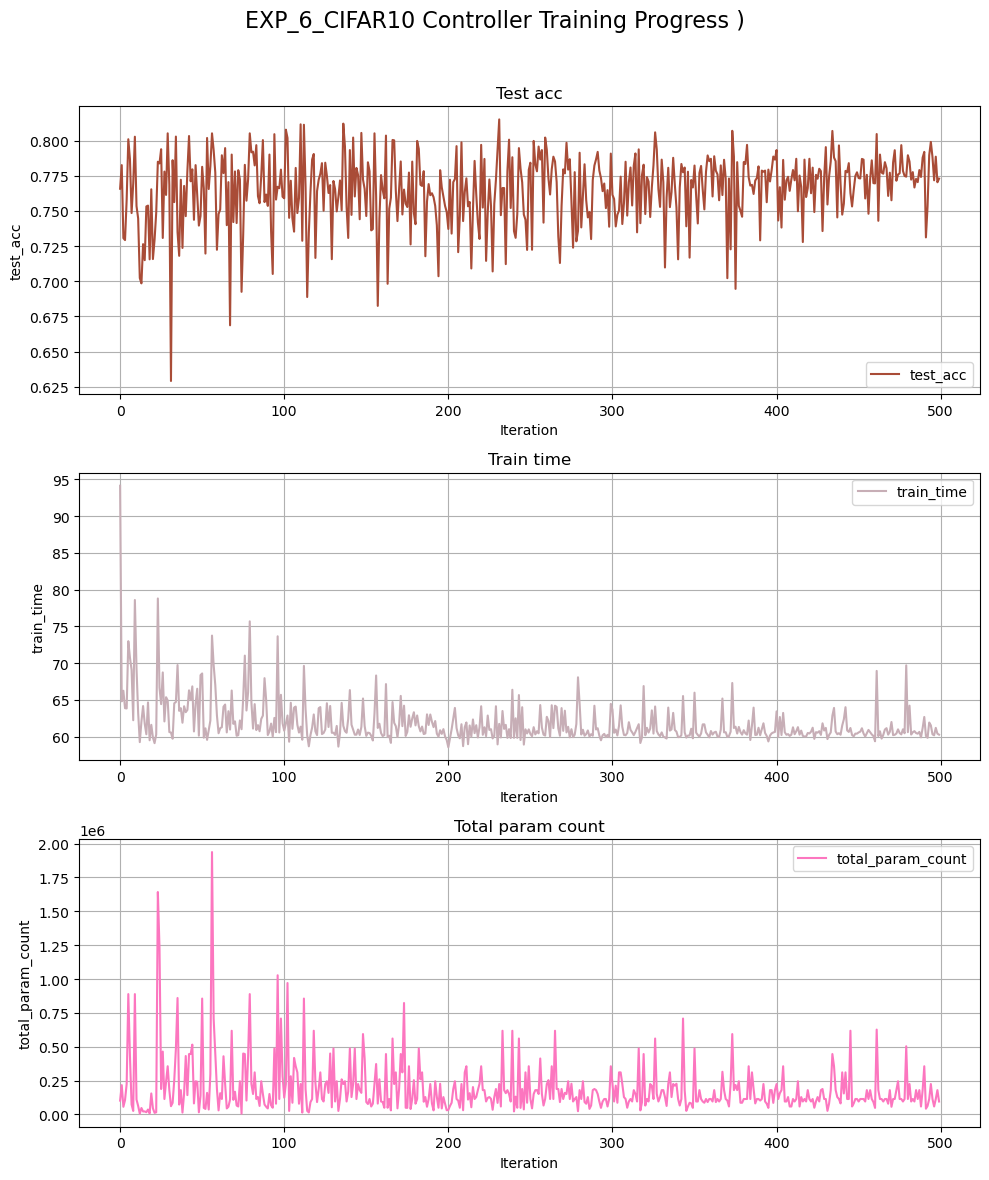

In [66]:
plot_metrics(combined_df, experiment_name=experiment_name, metrics=["test_acc", "train_time", "total_param_count"])

In [11]:
def compare_metrics(df_list, df_names, df_colors, metrics=None, labels=None, titles=None, limit=None):
    if limit is not None:
        for i, df in enumerate(df_list):
            df_list[i] = df.head(limit)

    if metrics is None:
        metrics = df1.columns
    else:
        for m in metrics:
            for df in df_list:
                if m not in df.columns:
                    raise ValueError(f"Metric '{m}' not found in progress data.")

    if labels is None:
        labels = { m: m for m in metrics }

    if titles is None:
        titles = { m: m.replace("_", " ").capitalize() for m in metrics }

    fig, axs = plt.subplots(len(metrics), 1, figsize=(15, 4 * len(metrics)))

    # fig, axs = plt.subplots(3, 1, figsize=(10, 12))
    fig.suptitle(" vs ".join(df_names), fontsize=16)

    for i, metric in enumerate(metrics):
        for j, df in enumerate(df_list):
            axs[i].plot(df[metric], label=labels[metric], color=df_colors[j])

        axs[i].set_title(titles[metric])
        axs[i].set_xlabel("Iteration")
        axs[i].set_ylabel(metric)
        axs[i].grid(True)
        axs[i].legend(df_names)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


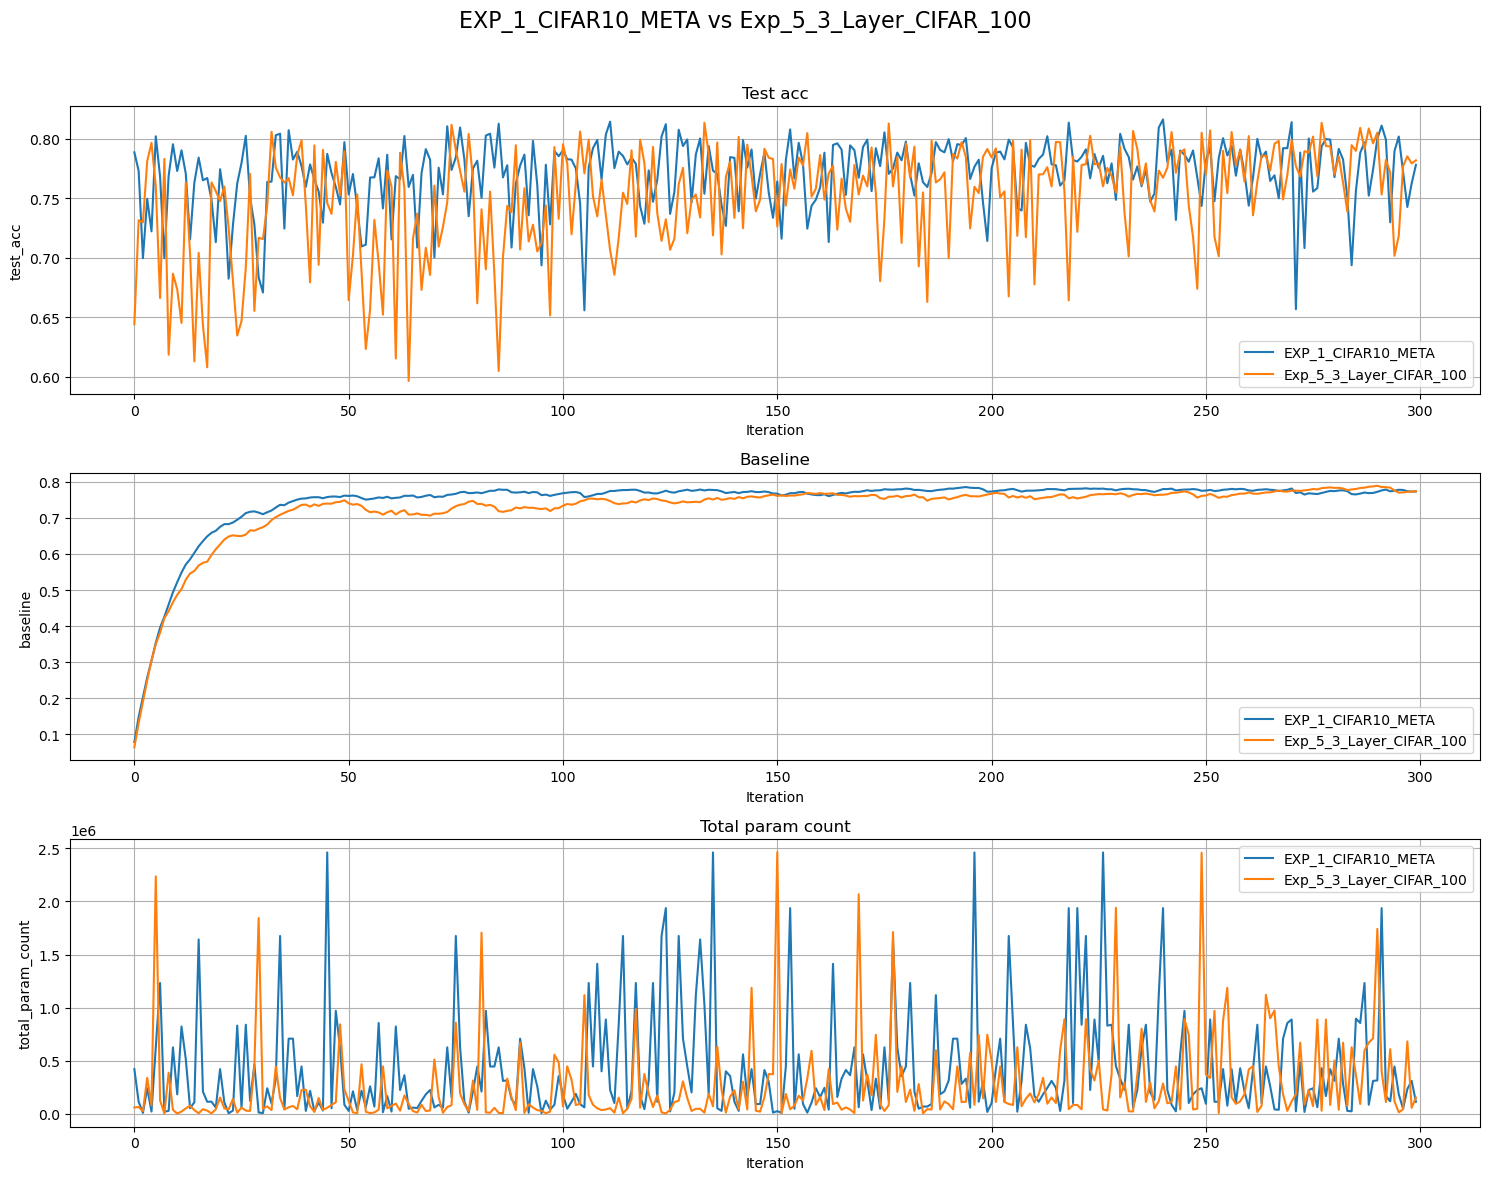

In [15]:
experiment_1_name = "EXP_1_CIFAR10_META"
experiment_2_name = "Exp_5_3_Layer_CIFAR_100"

df1 = get_combined_df(experiment_1_name)
df2 = get_combined_df(experiment_2_name)

compare_metrics([df1, df2], df_names=[experiment_1_name, experiment_2_name], df_colors=["tab:blue", "tab:orange"], metrics=["test_acc","baseline", "total_param_count"], limit=300)
